<a href="https://colab.research.google.com/github/jhamidi1/Data201-Spring/blob/main/Week_3_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/jhamidi1/Data201/refs/heads/main/Dataset/housing.csv"

df = pd.read_csv(url)
df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


# A. Scatterplots and Aesthetics

Scatterplot using matplotlib

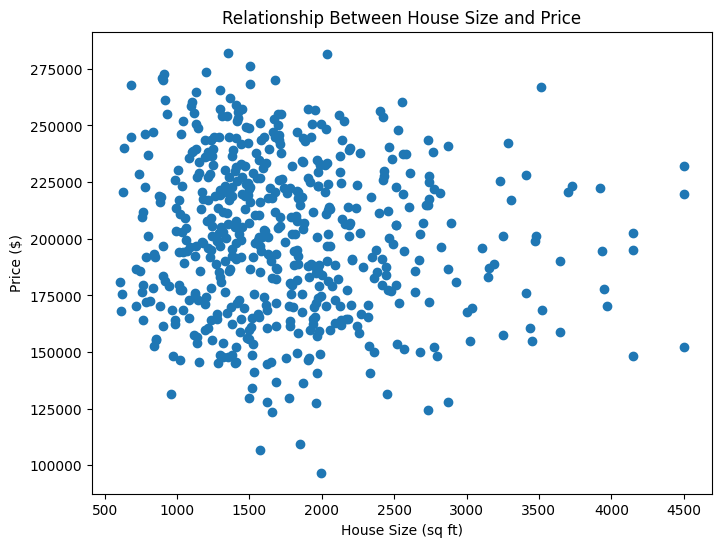

In [4]:
plt.figure(figsize=(8,6))
plt.scatter(df["size"], df["price"])

plt.xlabel("House Size (sq ft)")
plt.ylabel("Price")
plt.title("Relationship Between House Size and Price")

plt.show()

Scatterplot using seaborn

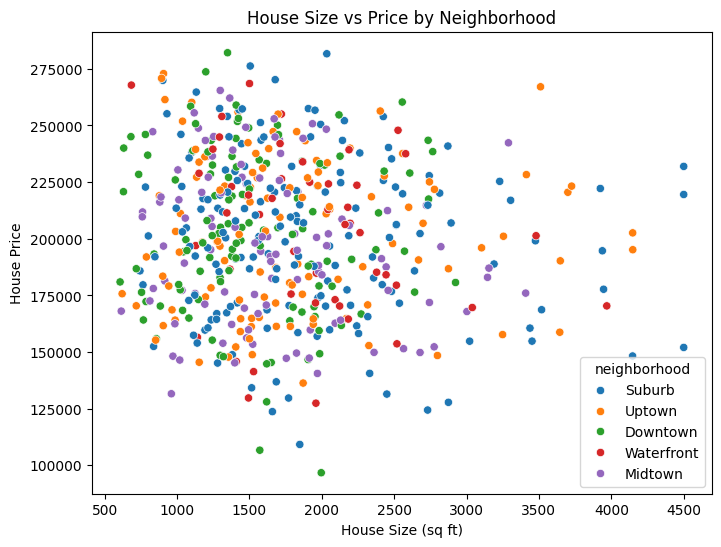

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="size",
    y="price",
    hue="neighborhood")

plt.xlabel("House Size (sq ft)")
plt.ylabel("House Price")
plt.title("House Size vs Price by Neighborhood")

plt.show()

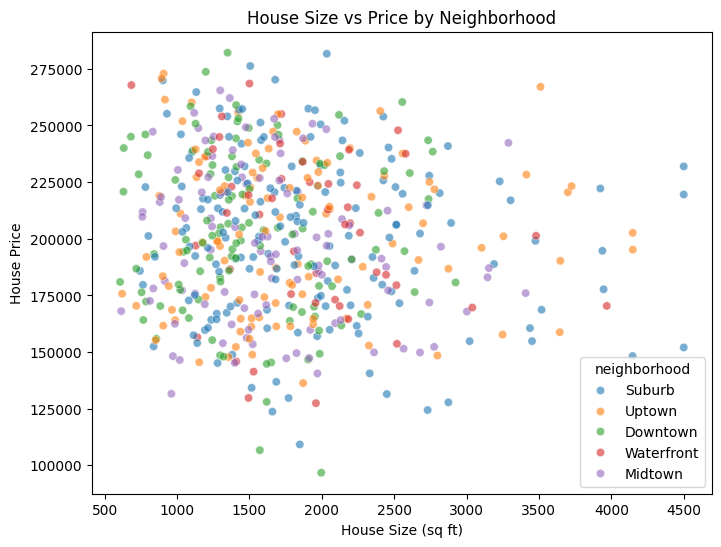

In [6]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="size",
    y="price",
    hue="neighborhood",
    alpha=0.6)

plt.xlabel("House Size (sq ft)")
plt.ylabel("House Price")
plt.title("House Size vs Price by Neighborhood")

plt.show()

What does seaborn automatically handle that matplotlib does not?

Seaborn handles grouping and coloring data based on categories using the hue parameter. It also makes legends without requiring extra code. In contrast, matplotlib usually requires manually separating the data and assigning colors for different groups.

Why is transparency useful here?

Transparency helps reduce overplotting when some points overlap in a scatterplot. By lowering the opacity, overlapping points visible and the dense areas of the data are easier to see.


# B. Small Multiples (Faceting)

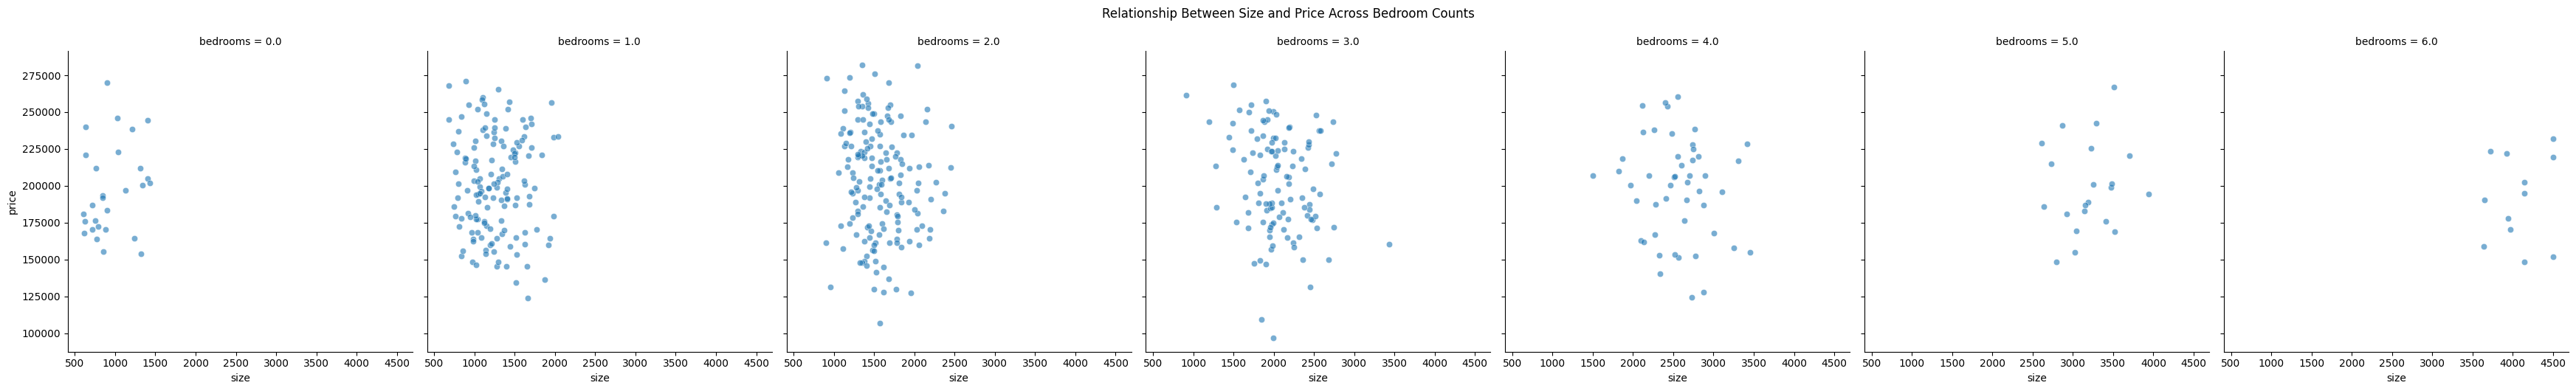

In [8]:
g = sns.relplot(
    data=df,
    x="size",
    y="price",
    col="bedrooms",
    alpha=0.6)

g.fig.suptitle("Relationship Between Size and Price Across Bedroom Counts", y=1.05)

plt.show()

Does the relationship between size and price look similar across bedroom counts?

Yes, the relationship between size and price appears similar across bedroom counts. In each subplot, larger homes generally have higher prices, showing a positive trend. Homes with more bedrooms also fall into higher price ranges. Overall, the pattern between size and price remains consistent across the different bedroom groups.

## C. Distribution and Categorical Plots

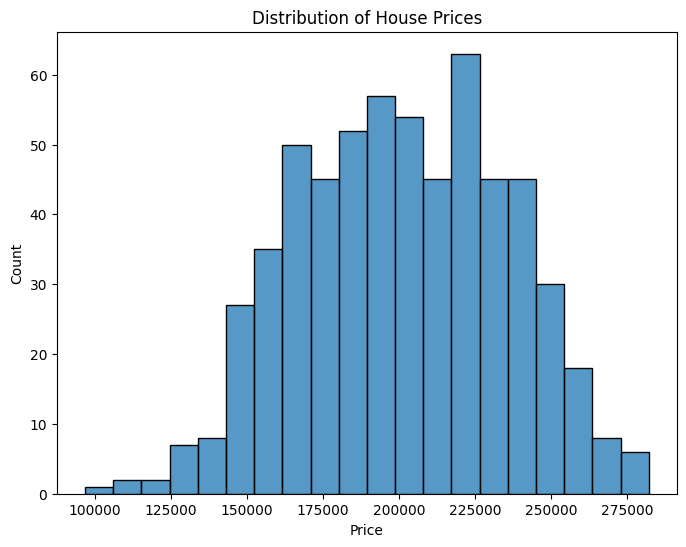

In [9]:
plt.figure(figsize=(8,6))
sns.histplot(df["price"], bins=20)

plt.xlabel("Price")
plt.title("Distribution of House Prices")

plt.show()

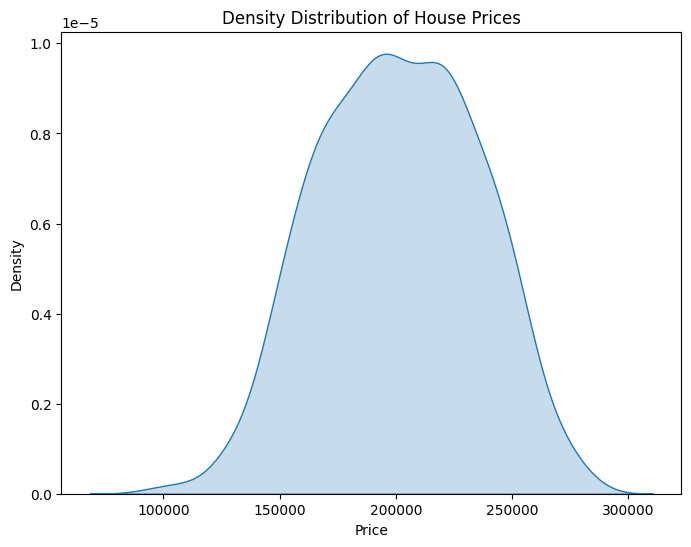

In [10]:
plt.figure(figsize=(8,6))
sns.kdeplot(df["price"], fill=True)

plt.xlabel("Price")
plt.title("Density Distribution of House Prices")

plt.show()

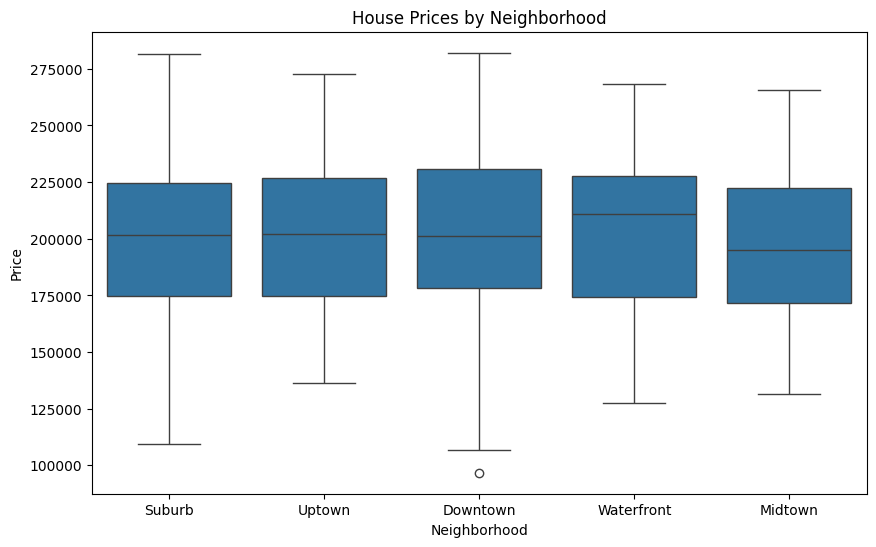

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="neighborhood",
    y="price"
)

plt.xlabel("Neighborhood")
plt.ylabel("Price")
plt.title("House Prices by Neighborhood")

plt.show()

Do neighborhoods differ systematically in price?
What visual evidence supports your claim?

Yes, neighborhoods show some differences in housing prices. The boxplot shows variations in the median prices and price ranges across neighborhoods. Some neighborhoods have slightly higher median prices and wider spreads. This indicates that location may influence housing prices.

# Part II -- Linear Regression for Inference (30 pts)

A. Multiple Regression (R → Python)

In [13]:
import statsmodels.formula.api as smf

In [14]:
model = smf.ols(
    formula="price ~ size + bedrooms + neighborhood",
    data=df).fit()

In [15]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.460
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.190
Time:                        03:29:40   Log-Likelihood:                -6212.8
No. Observations:                 524   AIC:                         1.244e+04
Df Residuals:                     517   BIC:                         1.247e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                   2.112e+05   4925.106     42.872      0.000    2.01e+05    2.21e+05
neighborhood[T.Midtown]    -4236.1877   4809.529     -0.881      0.379   -1.37e+04    5212.435
neighborhood[T.Suburb]      -562.7029   4369.989     -0.129      0.898   -9147.823    8022.417
neighborhood[T.Uptown]      1311.1025   4727.959      0.277      0.782   -7977.272    1.06e+04
neighborhood[T.Waterfront]  3001.3355   5984.299      0.502      0.616   -8755.198    1.48e+04
size                         -10.9345      4.210     -2.597      0.010     -19.205      -2.664
bedrooms                    4372.2643   2262.445      1.933      0.054     -72.453    8816.981
==============================================================================
Omnibus:                       12.814   Durbin-Watson:                   0.699
Prob(Omnibus):                  0.002   Jarque-Bera (JB):                7.598
Skew:                          -0.114   Prob(JB):                       0.0224
Kurtosis:                       2.456   Cond. No.                     1.05e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

B. Interpretation


1. Interpret the coefficient on size, explicitly stating what is being held constant.
The coefficient on size is −10.93, which means that for each additional unit increase in house size, the predicted house price decreases by about $10.93, holding bedrooms and neighborhood constant.

2. Is size statistically significant? How do you know?
Yes, size is statistically significant because its p-value is 0.010, which is less than the significance level of 0.05. This shows that there is statistically significant evidence that size is related to house price.

3. What does R² tell us in this context?
The R² value is 0.017, which means the model explains about 1.7% of the differences in house prices. This means that size, bedrooms, and neighborhood only explain a very small part of why house prices vary. Most of the changes in price are likely caused by other factors not in the model.




# Part IV -- Integrated Thinking (10 pts)

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
df = pd.read_csv(url)

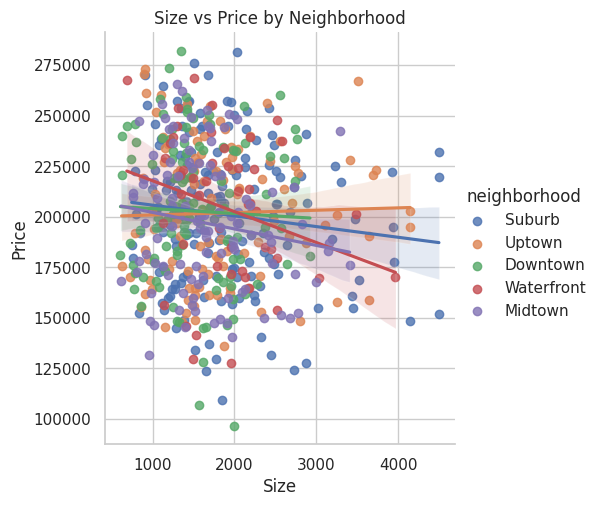

In [42]:
sns.lmplot(
    data=df,
    x="size",
    y="price",
    hue="neighborhood"
)

plt.title("Size vs Price by Neighborhood")
plt.xlabel("Size")
plt.ylabel("Price")

plt.show()

The regression model does not fully match what we saw earlier in the visualizations. In the earlier plots, it looked like larger homes generally had higher prices, suggesting a positive relationship between size and price. However, in the final regression figure, the lines slope slightly downward and the points are very scattered. This shows that the relationship between size and price is not very strong in the model. The visualization helped us see that the pattern might not be as strong as first.